## SAR Imagery Import

In [58]:
# import wandb
import torch
import pandas as pd
import numpy as np
import zipfile
import requests
from pathlib import Path

import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
os.environ['TORCH_USE_CUDA_DSA'] = '1'

# ---------------------------------------------------------------------------
# Box download URLs — fill these in with your shared links
# Box direct download format: https://company.box.com/shared/static/<id>
# ---------------------------------------------------------------------------
BOX_URLS = {
    "os1": "https://virginia.box.com/shared/static/9tz0fm7kq6745qzgy22hia985uf6c3hz.zip",   # e.g. "https://company.box.com/shared/static/abc123"
    "os2": "https://virginia.box.com/shared/static/t5dt2l6dgc3oz8oeizj83e8938gx69yr.zip",
    "fs":  "https://virginia.box.com/shared/static/u1lmcljm3o75gseghv5acnd4417qrkn2.zip",
}

# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------
PROJECT_ROOT = Path("..").resolve()
DATA_DIR     = PROJECT_ROOT / "data" / "classification"
DATA_DIR.mkdir(parents=True, exist_ok=True)


def download_and_extract(key: str, out_dir: Path) -> None:
    """Download a zip from Box and extract it to out_dir."""
    url = BOX_URLS[key]
    if not url:
        print(f"[{key}] No URL provided, skipping.")
        return
    if out_dir.exists() and any(out_dir.iterdir()):
        print(f"[{key}] Already extracted, skipping.")
        return
    zip_path = DATA_DIR / f"{key}.zip"
    print(f"[{key}] Downloading...")
    dl_url = url + ("?dl=1" if "?" not in url else "&dl=1")
    with requests.get(dl_url, stream=True) as r:
        r.raise_for_status()
        with open(zip_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=8192):
                f.write(chunk)
    print(f"[{key}] Extracting...")
    out_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(out_dir)
    zip_path.unlink()
    print(f"[{key}] Done -> {out_dir}")


# ---------------------------------------------------------------------------
# Download image folders
# ---------------------------------------------------------------------------
download_and_extract("os1", DATA_DIR / "os1")
download_and_extract("os2", DATA_DIR / "os2")
download_and_extract("fs",  DATA_DIR / "fs")

# ---------------------------------------------------------------------------
# Load CSVs (already in repo at data/classification/)
# ---------------------------------------------------------------------------
opensar1 = pd.read_csv(DATA_DIR / "opensar1_labels.csv")
opensar2 = pd.read_csv(DATA_DIR / "opensar2_labels.csv")
fusar    = pd.read_csv(DATA_DIR / "fusar_labels.csv")

# Resolve local image paths
opensar1["path"] = opensar1["path"].apply(lambda p: str(PROJECT_ROOT / p))
opensar2["path"] = opensar2["path"].apply(lambda p: str(PROJECT_ROOT / p))
fusar["path"]    = fusar["path"].apply(lambda p: str(PROJECT_ROOT / p))

print(f"OpenSARShip 1: {len(opensar1)} rows")
print(f"OpenSARShip 2: {len(opensar2)} rows")
print(f"FuSARShip:     {len(fusar)} rows")

fusar.head()

[os1] Already extracted, skipping.
[os2] Already extracted, skipping.
[fs] Already extracted, skipping.
OpenSARShip 1: 11346 rows
OpenSARShip 2: 18864 rows
FuSARShip:     5101 rows


,fs_id,path,class_label,ship_type,polarization,label,is_cargo,google_path
0,fs_0001,/sfs/gpfs/tardis/home/nbz3de/fold/ds6050_final...,Cargo/AggregatesCarrier,NaN,NaN,cargo,1,/content/drive/MyDrive/classification/fs/fs_00...
1,fs_0002,/sfs/gpfs/tardis/home/nbz3de/fold/ds6050_final...,Cargo/AggregatesCarrier,NaN,NaN,cargo,1,/content/drive/MyDrive/classification/fs/fs_00...
2,fs_0003,/sfs/gpfs/tardis/home/nbz3de/fold/ds6050_final...,Cargo/BulkCarrier,NaN,NaN,cargo,1,/content/drive/MyDrive/classification/fs/fs_00...
3,fs_0004,/sfs/gpfs/tardis/home/nbz3de/fold/ds6050_final...,Cargo/BulkCarrier,NaN,NaN,cargo,1,/content/drive/MyDrive/classification/fs/fs_00...
4,fs_0005,/sfs/gpfs/tardis/home/nbz3de/fold/ds6050_final...,Cargo/BulkCarrier,NaN,NaN,cargo,1,/content/drive/MyDrive/classification/fs/fs_00...


In [59]:
# import wandb
import torch
import pandas as pd
import numpy as np
from pathlib import Path
import gdown

DRIVE_FOLDER_URL = "https://drive.google.com/drive/folders/19jLMSzHChVLk-vVAg2muNN2OALzksWob"

# Local directory to download into — sits next to this notebook
PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data" / "classification"

# Download from Google Drive if CSVs are not already present
if not (DATA_DIR / "opensar1_labels.csv").exists():
    print("Downloading classification folder from Google Drive...")
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    gdown.download_folder(DRIVE_FOLDER_URL, output=str(DATA_DIR), quiet=False, use_cookies=False)
    print("Download complete.")
else:
    print(f"Data already present at {DATA_DIR}, skipping download.")

# Load all three label CSVs
opensar1 = pd.read_csv(DATA_DIR / "opensar1_labels.csv")
opensar2 = pd.read_csv(DATA_DIR / "opensar2_labels.csv")
fusar    = pd.read_csv(DATA_DIR / "fusar_labels.csv")

# Resolve image paths to absolute local paths
opensar1["path"] = opensar1["path"].apply(lambda p: str(PROJECT_ROOT / p))
opensar2["path"] = opensar2["path"].apply(lambda p: str(PROJECT_ROOT / p))
fusar["path"]    = fusar["path"].apply(lambda p: str(PROJECT_ROOT / p))

# print stats
print(f"OpenSARShip 1: {len(opensar1)} rows")
print(f"OpenSARShip 2: {len(opensar2)} rows")
print(f"FuSARShip:     {len(fusar)} rows")

fusar.head()

Data already present at /sfs/gpfs/tardis/home/nbz3de/fold/ds6050_final_project/data/classification, skipping download.
OpenSARShip 1: 11346 rows
OpenSARShip 2: 18864 rows
FuSARShip:     5101 rows


,fs_id,path,class_label,ship_type,polarization,label,is_cargo,google_path
0,fs_0001,/sfs/gpfs/tardis/home/nbz3de/fold/ds6050_final...,Cargo/AggregatesCarrier,NaN,NaN,cargo,1,/content/drive/MyDrive/classification/fs/fs_00...
1,fs_0002,/sfs/gpfs/tardis/home/nbz3de/fold/ds6050_final...,Cargo/AggregatesCarrier,NaN,NaN,cargo,1,/content/drive/MyDrive/classification/fs/fs_00...
2,fs_0003,/sfs/gpfs/tardis/home/nbz3de/fold/ds6050_final...,Cargo/BulkCarrier,NaN,NaN,cargo,1,/content/drive/MyDrive/classification/fs/fs_00...
3,fs_0004,/sfs/gpfs/tardis/home/nbz3de/fold/ds6050_final...,Cargo/BulkCarrier,NaN,NaN,cargo,1,/content/drive/MyDrive/classification/fs/fs_00...
4,fs_0005,/sfs/gpfs/tardis/home/nbz3de/fold/ds6050_final...,Cargo/BulkCarrier,NaN,NaN,cargo,1,/content/drive/MyDrive/classification/fs/fs_00...


## Label Mapping and Filtering

In [60]:
# Build mapping from all unique labels across all three datasets
unique_labels = sorted(set(opensar1['label']).union(
                       set(opensar2['label'])).union(
                       set(fusar['label'])))

label_to_int = {label: i for i, label in enumerate(unique_labels)}

# Apply mapping independently
opensar1.loc[:, 'label_id'] = opensar1['label'].map(label_to_int)
opensar2.loc[:, 'label_id'] = opensar2['label'].map(label_to_int)
fusar.loc[:, 'label_id']    = fusar['label'].map(label_to_int)

print("Label mapping:", label_to_int)

# drop unknown values of the datasets
opensar1 = opensar1[opensar1['label'] != 'unknown']
opensar2 = opensar2[opensar2['label'] != 'unknown']
fusar    = fusar[fusar['label'] != 'unknown']

# length after creation
print(f"OpenSARShip 1: {len(opensar1)} rows")
print(f"OpenSARShip 2: {len(opensar2)} rows")
print(f"FuSARShip:     {len(fusar)} rows")

Label mapping: {'cargo': 0, 'engineering': 1, 'other': 2, 'passenger': 3, 'tanker': 4, 'unknown': 5}
OpenSARShip 1: 10602 rows
OpenSARShip 2: 16280 rows
FuSARShip:     5101 rows


## Dataset Creation

In [61]:
# create the dataset
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import ConcatDataset
from torchvision import transforms
from PIL import Image
import os

class create_dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        try:
            image = Image.open(row['path']).convert('L')  # load as grayscale
        except (FileNotFoundError, OSError) as e:
            raise RuntimeError(f"Error loading image at index {idx}: {row['path']}") from e

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(row['label_id'], dtype=torch.long)


# ImageNet normalization values expected by pretrained ResNet
RESNET_MEAN = [0.485, 0.456, 0.406]
RESNET_STD  = [0.229, 0.224, 0.225]

# Training transform — includes augmentation
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15, fill=0),
    transforms.ToTensor(),
    transforms.Normalize(mean=RESNET_MEAN, std=RESNET_STD)
])

# Validation/test transform — no augmentation
transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=RESNET_MEAN, std=RESNET_STD)
])

# Create two versions of each dataset: one for train, one for val/test
datasets_train = {
    'os1'  : create_dataset(opensar1, transform=transform_train),
    'os2'  : create_dataset(opensar2, transform=transform_train),
    'fusar': create_dataset(fusar,    transform=transform_train),
}
datasets_val = {
    'os1'  : create_dataset(opensar1, transform=transform_val),
    'os2'  : create_dataset(opensar2, transform=transform_val),
    'fusar': create_dataset(fusar,    transform=transform_val),
}

# Add combined entries
datasets_train['all'] = ConcatDataset(datasets_train.values())
datasets_val['all']   = ConcatDataset(datasets_val.values())

print(f"OpenSARShip 1: {len(datasets_train['os1'])} samples")
print(f"OpenSARShip 2: {len(datasets_train['os2'])} samples")
print(f"FuSARShip:     {len(datasets_train['fusar'])} samples")
print(f"Combined:      {len(datasets_train['all'])} samples")

OpenSARShip 1: 10602 samples
OpenSARShip 2: 16280 samples
FuSARShip:     5101 samples
Combined:      31983 samples


## Train Test Val Split

In [62]:
from torch.utils.data import Subset
from sklearn.model_selection import train_test_split

# Add a source column before concatenating
opensar1['source'] = 'os1'
opensar2['source'] = 'os2'
fusar['source']    = 'fusar'

domains = {
    'os1'  : {'df': opensar1},
    'os2'  : {'df': opensar2},
    'fusar': {'df': fusar},
    'all'  : {'df': pd.concat([opensar1, opensar2, fusar], ignore_index=True)},
}

# ── Step 1: Split each source domain independently ───────────────────────────
for key in ['os1', 'os2', 'fusar']:
    df     = domains[key]['df']
    labels = df['label_id'].values

    trainval_idx, test_idx = train_test_split(
        range(len(df)),
        test_size=0.2,
        stratify=labels,
        random_state=42
    )
    train_idx, val_idx = train_test_split(
        trainval_idx,
        test_size=0.1,
        stratify=labels[trainval_idx],
        random_state=42
    )

    domains[key]['train_idx'] = list(train_idx)
    domains[key]['val_idx']   = list(val_idx)
    domains[key]['test_idx']  = list(test_idx)
    domains[key]['train_dataset'] = Subset(datasets_train[key], train_idx)
    domains[key]['val_dataset']   = Subset(datasets_val[key],   val_idx)
    domains[key]['test_dataset']  = Subset(datasets_val[key],   test_idx)

    print(f"Domain: {key}")
    print(f"  Train:      {len(train_idx)}")
    print(f"  Validation: {len(val_idx)}")
    print(f"  Test:       {len(test_idx)}")

    for split_name, split_idx in [('Train', train_idx), ('Val', val_idx), ('Test', test_idx)]:
        split_labels = labels[split_idx]
        unique, counts = np.unique(split_labels, return_counts=True)
        print(f"  {split_name} class breakdown:")
        for cls, cnt in zip(unique, counts):
            print(f"    class {cls}: {cnt:4d} ({cnt/len(split_idx)*100:.1f}%)")

# ── Step 2: Build 'all' by offsetting and combining per-source splits ─────────
os1_len   = len(domains['os1']['df'])
os2_len   = len(domains['os2']['df'])

all_train_idx = (
    list(domains['os1']['train_idx']) +
    [i + os1_len for i in domains['os2']['train_idx']] +
    [i + os1_len + os2_len for i in domains['fusar']['train_idx']]
)
all_val_idx = (
    list(domains['os1']['val_idx']) +
    [i + os1_len for i in domains['os2']['val_idx']] +
    [i + os1_len + os2_len for i in domains['fusar']['val_idx']]
)
all_test_idx = (
    list(domains['os1']['test_idx']) +
    [i + os1_len for i in domains['os2']['test_idx']] +
    [i + os1_len + os2_len for i in domains['fusar']['test_idx']]
)

full_train_ds = ConcatDataset(datasets_train.values())
full_val_ds   = ConcatDataset(datasets_val.values())

domains['all']['train_idx']     = all_train_idx
domains['all']['val_idx']       = all_val_idx
domains['all']['test_idx']      = all_test_idx
domains['all']['train_dataset'] = Subset(full_train_ds, all_train_idx)
domains['all']['val_dataset']   = Subset(full_val_ds,   all_val_idx)
domains['all']['test_dataset']  = Subset(full_val_ds,   all_test_idx)

# Print 'all' breakdown
df_all = domains['all']['df']
labels_all = df_all['label_id'].values
print(f"Domain: all")
print(f"  Train:      {len(all_train_idx)}")
print(f"  Validation: {len(all_val_idx)}")
print(f"  Test:       {len(all_test_idx)}")

for source in ['os1', 'os2', 'fusar']:
    source_mask = (df_all['source'] == source).values
    train_pct = source_mask[all_train_idx].sum() / len(all_train_idx) * 100
    val_pct   = source_mask[all_val_idx].sum()   / len(all_val_idx)   * 100
    test_pct  = source_mask[all_test_idx].sum()  / len(all_test_idx)  * 100
    print(f"  {source} breakdown -> train: {train_pct:.1f}%  val: {val_pct:.1f}%  test: {test_pct:.1f}%")

for split_name, split_idx in [('Train', all_train_idx), ('Val', all_val_idx), ('Test', all_test_idx)]:
    split_labels = labels_all[split_idx]
    unique, counts = np.unique(split_labels, return_counts=True)
    print(f"  {split_name} class breakdown:")
    for cls, cnt in zip(unique, counts):
        print(f"    class {cls}: {cnt:4d} ({cnt/len(split_idx)*100:.1f}%)")

# ── Save indices ──────────────────────────────────────────────────────────────
np.savez('misc/vis_indices.npz', **{
    f"{key}__{split}": np.array(indices)
    for key in domains
    for split, indices in [
        ('train_idx', domains[key]['train_idx']),
        ('val_idx',   domains[key]['val_idx']),
        ('test_idx',  domains[key]['test_idx']),
    ]
})

Domain: os1
  Train:      7632
  Validation: 849
  Test:       2121
  Train class breakdown:
    class 0: 5932 (77.7%)
    class 1:  195 (2.6%)
    class 2:  276 (3.6%)
    class 3:   27 (0.4%)
    class 4: 1202 (15.7%)
  Val class breakdown:
    class 0:  660 (77.7%)
    class 1:   21 (2.5%)
    class 2:   31 (3.7%)
    class 3:    3 (0.4%)
    class 4:  134 (15.8%)
  Test class breakdown:
    class 0: 1648 (77.7%)
    class 1:   54 (2.5%)
    class 2:   77 (3.6%)
    class 3:    8 (0.4%)
    class 4:  334 (15.7%)
Domain: os2
  Train:      11721
  Validation: 1303
  Test:       3256
  Train class breakdown:
    class 0: 7842 (66.9%)
    class 1:  337 (2.9%)
    class 2:  631 (5.4%)
    class 3:  100 (0.9%)
    class 4: 2811 (24.0%)
  Val class breakdown:
    class 0:  872 (66.9%)
    class 1:   37 (2.8%)
    class 2:   70 (5.4%)
    class 3:   11 (0.8%)
    class 4:  313 (24.0%)
  Test class breakdown:
    class 0: 2179 (66.9%)
    class 1:   93 (2.9%)
    class 2:  175 (5.4%)
    cla

In [63]:
batch_size = 32

# loop through and create dataloaders for each dataset
for key in domains:
    nw = 0 if key == 'fusar' else 2
    pw = False if key == 'fusar' else True
    pm = False if key == 'fusar' else True

    domains[key]['train_loader'] = DataLoader(domains[key]['train_dataset'], batch_size=batch_size, shuffle=True,  num_workers=nw, pin_memory=pm, persistent_workers=pw)
    domains[key]['val_loader']   = DataLoader(domains[key]['val_dataset'],   batch_size=batch_size, shuffle=False, num_workers=nw, pin_memory=pm, persistent_workers=pw)
    domains[key]['test_loader']  = DataLoader(domains[key]['test_dataset'],  batch_size=batch_size, shuffle=False, num_workers=nw, pin_memory=pm, persistent_workers=pw)

    print(f"{key} — train: {len(domains[key]['train_loader'])} batches | "
          f"val: {len(domains[key]['val_loader'])} batches | "
          f"test: {len(domains[key]['test_loader'])} batches")

os1 — train: 239 batches | val: 27 batches | test: 67 batches
os2 — train: 367 batches | val: 41 batches | test: 102 batches
fusar — train: 115 batches | val: 13 batches | test: 32 batches
all — train: 720 batches | val: 80 batches | test: 200 batches


## Model Training

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import Module, CrossEntropyLoss, Linear
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
from torchvision.models import swin_t, Swin_T_Weights
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import time

class_names = sorted(domains['all']['df']['label'].unique().tolist())
print(f"class_names ({len(class_names)}): {class_names}")


class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None, reduction='mean'):
        super().__init__()
        self.gamma     = gamma
        self.weight    = weight
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss    = F.cross_entropy(inputs, targets, weight=self.weight, reduction='none')
        pt         = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss

def train_model(model, model_name, class_names, train_loader, val_loader,
                train_labels, epochs=10, lr=5e-5, warmup=True):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model  = model.to(device)
    print(device)
    print(torch.cuda.is_available())
    print(torch.cuda.get_device_name(0))
    print(next(model.parameters()).device)

    # ── Focal loss ───────────────────────────────────────────────────────
    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(train_labels),
        y=train_labels
    )
    class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = FocalLoss(gamma=2.0)
    # ─────────────────────────────────────────────────────────────────────

    optimizer = AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=1e-2
    )

    # ── Scheduler: optional warmup then cosine decay ─────────────────────
    if warmup:
        warmup_sched = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=2)
        cosine_sched = CosineAnnealingLR(optimizer, T_max=epochs - 2, eta_min=1e-6)
        scheduler    = SequentialLR(optimizer, schedulers=[warmup_sched, cosine_sched], milestones=[2])
    else:
        scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    # ─────────────────────────────────────────────────────────────────────

    best_val_acc = 0
    train_losses, val_losses = [], []
    train_accs,   val_accs   = [], []

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0, 0, 0

        for i, (inputs, labels) in enumerate(train_loader):
            t0 = time.time()
            inputs, labels = inputs.to(device), labels.to(device)
            t1 = time.time()
            optimizer.zero_grad()
            outputs = model(inputs)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            t2 = time.time()

            if i == 0 and epoch == 0:
                print(f"Data->GPU: {t1-t0:.3f}s | Forward+backward: {t2-t1:.3f}s")

            running_loss += loss.item()
            _, predicted  = outputs.max(1)
            total        += labels.size(0)
            correct      += predicted.eq(labels).sum().item()

        scheduler.step()

        train_loss = running_loss / len(train_loader)
        train_acc  = 100. * correct / total

        model.eval()
        val_loss, correct, total = 0, 0, 0
        all_preds, all_labels    = [], []

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs        = model(inputs)
                loss           = criterion(outputs, labels)
                val_loss      += loss.item()
                _, predicted   = outputs.max(1)
                total         += labels.size(0)
                correct       += predicted.eq(labels).sum().item()
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_loss     = val_loss / len(val_loader)
        val_acc      = 100. * correct / total
        current_lr   = scheduler.get_last_lr()[0]

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f"weights/{model_name}_baseline_vis.pth")

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"[{model_name}] Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
              f"Val Acc: {val_acc:.2f}% | LR: {current_lr:.2e}")

    history = {
        "train_loss": train_losses,
        "val_loss":   val_losses,
        "train_acc":  train_accs,
        "val_acc":    val_accs,
    }

    return model, history

class_names (5): ['cargo', 'engineering', 'other', 'passenger', 'tanker']


In [65]:
from torch.nn import Module, CrossEntropyLoss, Linear
import torch
import torch.nn as nn
from torchvision.models import swin_t, Swin_T_Weights

class_names = sorted(domains['all']['df']['label'].unique().tolist())
print(f"class_names ({len(class_names)}): {class_names}")

class swin_transfer(nn.Module):
    """
    Swin-T transfer learning for SAR ship classification.
    Early stages frozen; stage 3, stage 4, norm, and head are trainable.
    """

    def __init__(self, num_classes: int):
        super().__init__()
        backbone = swin_t(weights=Swin_T_Weights.IMAGENET1K_V1)

        self.features = backbone.features
        self.norm     = backbone.norm

        # Swin-T output dim is 768
        self.head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(768, num_classes)
        )

        # Freeze all first
        for p in self.parameters():
            p.requires_grad = False

        # Unfreeze last two stages, norm, and head
        for m in (self.features[6], self.features[7], self.norm, self.head):
            for p in m.parameters():
                p.requires_grad = True

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)     # (B, H, W, C) — Swin is channels last
        x = self.norm(x)         # (B, H, W, C)
        x = x.mean(dim=[1, 2])  # (B, C=768)   — global avg pool over H, W
        return self.head(x)      # (B, num_classes)

class_names (5): ['cargo', 'engineering', 'other', 'passenger', 'tanker']


In [66]:
def sanity_check(model, model_name, train_loader, val_loader, num_batches=20):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    criterion = CrossEntropyLoss()
    optimizer = Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

    model.train()
    for i, (inputs, labels) in enumerate(train_loader):
        if i >= num_batches:
            break
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        print(f"[{model_name}] Batch {i+1}/{num_batches} | Loss: {loss.item():.4f}")

In [67]:
for key in domains:
    domains[key]['model'] = swin_transfer(num_classes=len(class_names))
    sanity_check(domains[key]['model'], key, domains[key]['train_loader'], domains[key]['val_loader'], num_batches=5)

[os1] Batch 1/5 | Loss: 1.8117
[os1] Batch 2/5 | Loss: 1.4241
[os1] Batch 3/5 | Loss: 1.1241
[os1] Batch 4/5 | Loss: 0.7894
[os1] Batch 5/5 | Loss: 0.8755
[os2] Batch 1/5 | Loss: 1.8472
[os2] Batch 2/5 | Loss: 1.4401
[os2] Batch 3/5 | Loss: 1.1560
[os2] Batch 4/5 | Loss: 1.1431
[os2] Batch 5/5 | Loss: 1.0396
[fusar] Batch 1/5 | Loss: 1.5681
[fusar] Batch 2/5 | Loss: 1.2556
[fusar] Batch 3/5 | Loss: 1.2693
[fusar] Batch 4/5 | Loss: 1.3111
[fusar] Batch 5/5 | Loss: 1.1263
[all] Batch 1/5 | Loss: 1.5903
[all] Batch 2/5 | Loss: 1.4811
[all] Batch 3/5 | Loss: 1.3120
[all] Batch 4/5 | Loss: 0.9520
[all] Batch 5/5 | Loss: 1.1373


In [68]:
import gc
import torch

def clear_cache():
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    print(f"GPU memory allocated: {torch.cuda.memory_allocated()/1e9:.2f}GB")
    print(f"GPU memory reserved:  {torch.cuda.memory_reserved()/1e9:.2f}GB")

for key in domains:
    clear_cache()
    domains[key]['model'] = swin_transfer(num_classes=len(class_names))

    train_labels = domains[key]['df']['label_id'].values[domains[key]['train_idx']]

    domains[key]['trained_model'], domains[key]['history'] = train_model(
        domains[key]['model'], key, class_names,
        domains[key]['train_loader'], domains[key]['val_loader'],
        train_labels=train_labels,
        epochs=10, lr=5e-5
    )
    domains[key]['trained_model'] = domains[key]['trained_model'].cpu()
    clear_cache()

GPU memory allocated: 1.04GB
GPU memory reserved:  1.87GB
cuda
True
NVIDIA GeForce RTX 3090
cuda:0
Data->GPU: 0.003s | Forward+backward: 0.076s
[os1] Epoch 1/10 | Train Loss: 0.4897 | Val Loss: 0.3059 | Val Acc: 77.39% | LR: 2.75e-05
[os1] Epoch 2/10 | Train Loss: 0.3134 | Val Loss: 0.2761 | Val Acc: 77.62% | LR: 5.00e-05
[os1] Epoch 3/10 | Train Loss: 0.2924 | Val Loss: 0.2745 | Val Acc: 77.97% | LR: 4.81e-05
[os1] Epoch 4/10 | Train Loss: 0.2862 | Val Loss: 0.2634 | Val Acc: 78.45% | LR: 4.28e-05
[os1] Epoch 5/10 | Train Loss: 0.2790 | Val Loss: 0.2620 | Val Acc: 77.62% | LR: 3.49e-05
[os1] Epoch 6/10 | Train Loss: 0.2742 | Val Loss: 0.2651 | Val Acc: 78.80% | LR: 2.55e-05
[os1] Epoch 7/10 | Train Loss: 0.2699 | Val Loss: 0.2640 | Val Acc: 78.45% | LR: 1.61e-05
[os1] Epoch 8/10 | Train Loss: 0.2675 | Val Loss: 0.2574 | Val Acc: 78.21% | LR: 8.18e-06
[os1] Epoch 9/10 | Train Loss: 0.2633 | Val Loss: 0.2570 | Val Acc: 78.56% | LR: 2.86e-06
[os1] Epoch 10/10 | Train Loss: 0.2614 | Val L

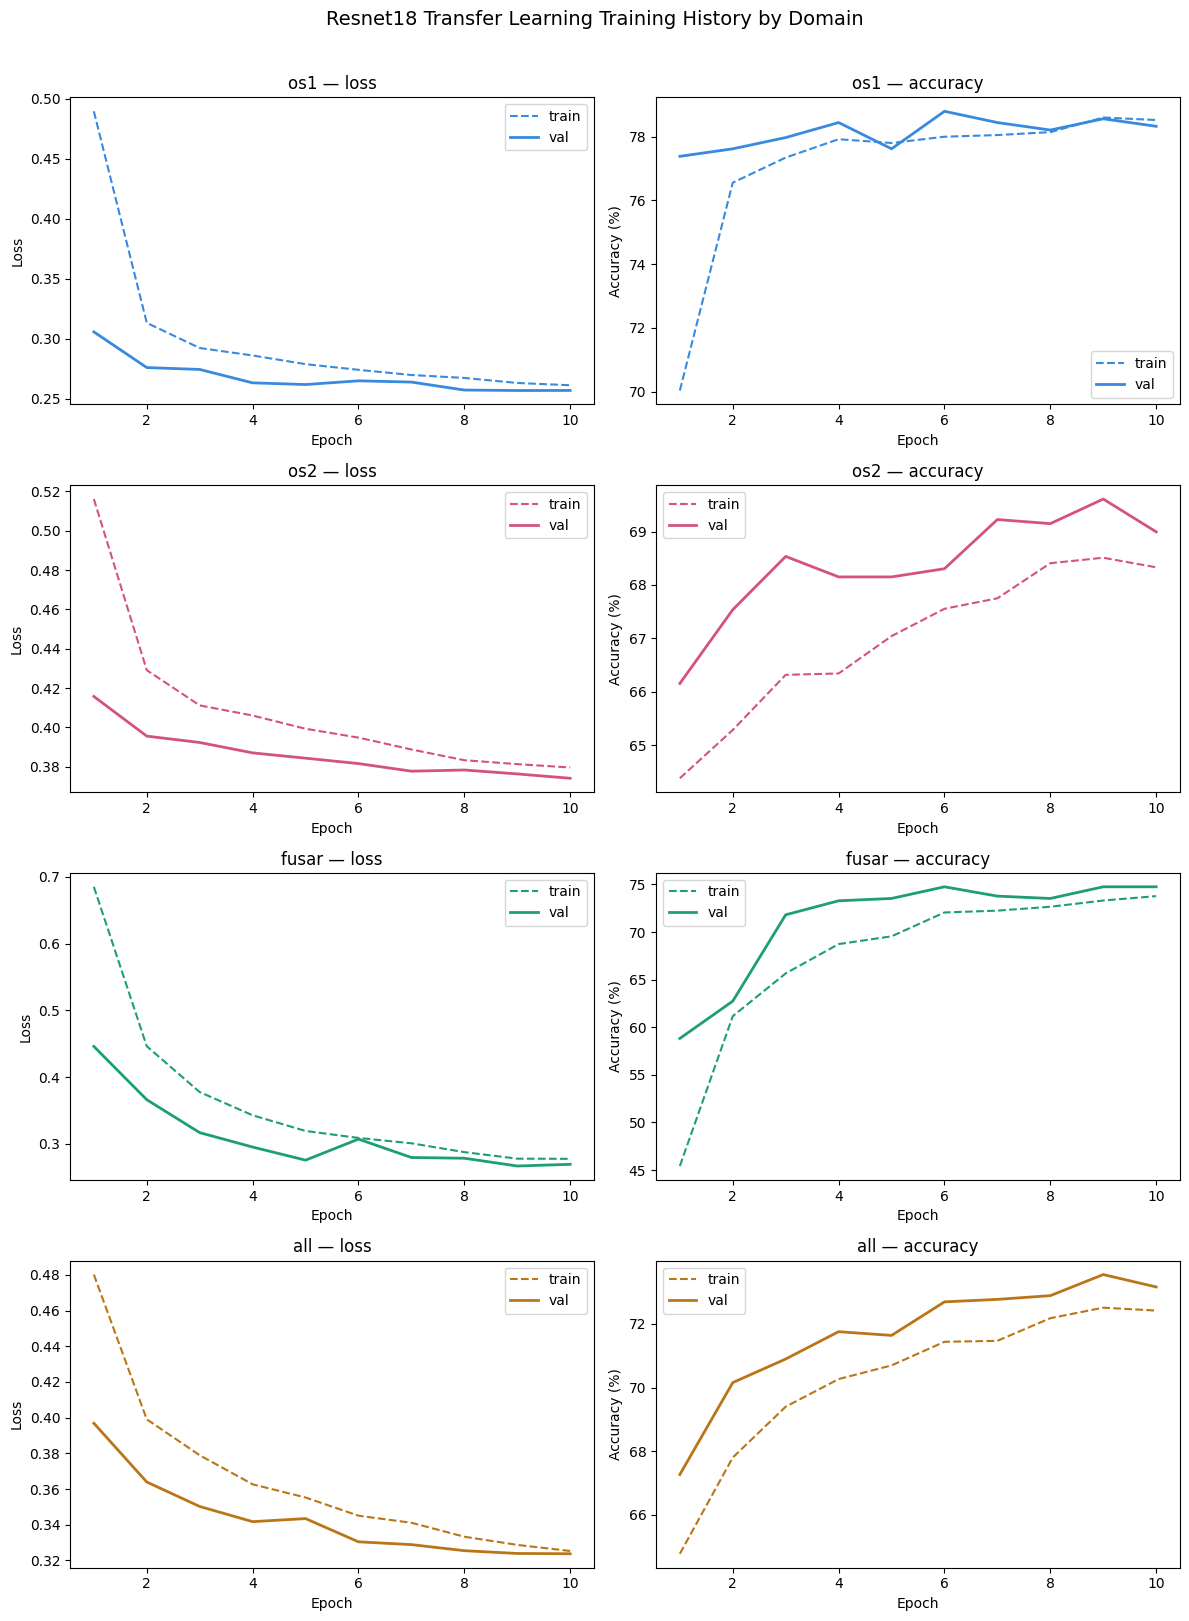

Saved: ['os1', 'os2', 'fusar', 'all']


In [69]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def plot_history_subplots(domains):
    keys = [k for k in domains if 'history' in domains[k]]
    colors = {'os1': '#378ADD', 'os2': '#D4537E', 'fusar': '#1D9E75', 'all': '#BA7517'}

    fig, axes = plt.subplots(len(keys), 2, figsize=(12, 4 * len(keys)))
    fig.suptitle("Resnet18 Transfer Learning Training History by Domain", fontsize=14, y=1.01)

    for i, key in enumerate(keys):
        h     = domains[key]['history']
        color = colors.get(key, 'steelblue')
        epochs = range(1, len(h['train_loss']) + 1)

        # Loss
        ax1 = axes[i, 0]
        ax1.plot(epochs, h['train_loss'], linestyle='dashed', color=color, label='train')
        ax1.plot(epochs, h['val_loss'],   linestyle='solid',  color=color, label='val', linewidth=2)
        ax1.set_title(f"{key} — loss")
        ax1.set_xlabel("Epoch")
        ax1.set_ylabel("Loss")
        ax1.legend()

        # Accuracy
        ax2 = axes[i, 1]
        ax2.plot(epochs, h['train_acc'], linestyle='dashed', color=color, label='train')
        ax2.plot(epochs, h['val_acc'],   linestyle='solid',  color=color, label='val', linewidth=2)
        ax2.set_title(f"{key} — accuracy")
        ax2.set_xlabel("Epoch")
        ax2.set_ylabel("Accuracy (%)")
        ax2.legend()

    plt.tight_layout()
    plt.savefig("misc/baseline_vis_history.png", dpi=150, bbox_inches='tight')
    plt.show()

plot_history_subplots(domains)


# save off the training history data
import json

history_data = {key: domains[key]['history'] for key in domains if 'history' in domains[key]}

with open('misc/baseline_vis_history.json', 'w') as f:
    json.dump(history_data, f, indent=2)

print("Saved:", list(history_data.keys()))